# Exercises: Hypothesis Testing

**A Waiter's Tips**

The following description was retrieved from Kaggle page.

> Food servers’ tips in restaurants may be influenced by many factors, including the nature of the restaurant, size of the party, and table locations in the restaurant. Restaurant managers need to know which factors matter when they assign tables to food servers. For the sake of staff morale, they usually want to avoid either the substance or the appearance of unfair treatment of the servers, for whom tips (at least in restaurants in the United States) are a major component of pay. In one restaurant, a food server recorded the following data on all customers they served during an interval of two and a half months in early 1990. The restaurant, located in a suburban shopping mall, was part of a national chain and served a varied menu. In observance of local law, the restaurant offered to seat in a non-smoking section to patrons who requested it. Each record includes a day and time, and taken together, they show the server’s work schedule.

Acknowledgements The data was reported in a collection of case studies for business statistics. Bryant, P. G. and Smith, M (1995) Practical Data Analysis: Case Studies in Business Statistics. Homewood, IL: Richard D. Irwin Publishing

The dataset is also available through the Python package Seaborn.

In [1]:
import seaborn as sns

tips = sns.load_dataset("tips")

Here's a description of each column in the dataset:

- `total_bill`: The total bill amount, including the cost of food and drinks.
- `tip`: The tip amount given by the customer.
- `sex`: The gender of the customer (e.g., Male or Female).
- `smoker`: Whether the customer is a smoker or not (e.g., Yes or No).
- `day`: The day of the week when the transaction occurred (e.g., Sun, Sat, Thu, etc.).
- `time`: The time of day when the transaction occurred, typically categorized as Lunch or Dinner.
- `size`: The size of the party or group of customers.

**Your Task**: is to accept or reject the following hypothesis using statistical testing:

- Hypothesis $H_1$: smoking is associated with time of visit
- Hypothesis $H_2$: the bigger the group the higher the tip
- Hypothesis $H_3$: group size is different based on the time of visit
- Hypothesis $H_4$: (... come up with a hypothesis of your own ...)
- Finally, analyze if size (party size) is a **confounder**. That is, does a larger party cause a higher tip, or simply a higher bill which then leads to a higher tip?

# **Answers:**

The decision to reject or fail to reject the null hypothesis (H₀) is based entirely on the p‑value, so printing onlythe p‑value is sufficient. That’s why I chose to display just the p‑value in my output.
* If p < 0.05 → reject H₀. There is a statistically significant effect.
* If p ≥ 0.05 → fail to reject H₀. There is no statistically significant effect.

In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Hypothesis H1: smoking is associated with time of visit:

**Variables:** smoker (Categorical) and time of visit (Categorical).

**Test:** Chi-Square Test of Independence.

**Hypotheses:**

* H0 (null): Smoking and time of visit are independent.
* H1 (alt): Smoking and time of visit are associated.

In [3]:
frequency_table = pd.crosstab(tips['smoker'], tips['time'])
chi2, p, dof, expected = stats.chi2_contingency(frequency_table)
print("The p-value is:" , round(p,3))

The p-value is: 0.477


**Explain:**

Since the output of p value = 0.477 > 0.05, We fail to reject the null hypothesis H₀ . So smoking is NOT significantly associated with time of visit.

# Hypothesis H2: the bigger the group the higher the tip:

**Variables:** size (Numerical) and tip (Numerical).

**Test:** Correlation (Pearson or Spearman).

**Hypotheses:**

* H0 (null): There is no correlation between group size and tip.
* H1 (alt): There is a positive correlation between group size and tip.

In [4]:
# Pearson’s correlation coefficient

r, p_value = stats.pearsonr(tips["size"], tips["tip"])
print("The Correlation coefficient (r) is:" , round(r , 3))
print("The p-value is:" , p_value)

The Correlation coefficient (r) is: 0.489
The p-value is: 4.300543327224998e-16


**Explain:**
* The correlation coefficient (r) = 0.489 > 0, There is a moderate positive correlation. Meaning when the group size increases, the tip amount tends to increase.
* The p‑value = 4.300543327224998e‑16 < 0.05 (this number is extremely small basically a zero). Since p‑value < 0.05 we reject the null hypothesis H₀ , meaning the relationship is statistically significant and not likely due to random chance.




# Hypothesis H3 : group size is different based on the time of visit:


**Variables:** size (numerical) and time(categorical)

**Test:** independent t‑test

**Hypotheses:**
* H0 (null): Party size distribution is the same for Lunch and Dinner.
* H1(alt): Group sizes differ between Lunch and Dinner.

In [5]:
lunch = tips[tips['time']=='Lunch']['size']
dinner = tips[tips['time']=='Dinner']['size']
t_stat, p_value = stats.ttest_ind(lunch, dinner, equal_var=False)
print("P-value is:", round(p_value,4))

P-value is: 0.1302


**Explain:**

Since the p‑value 0.130 > 0.05, we fail to reject the null hypothesis H₀. This means there is no statistically significant difference in group size between lunch and dinner. We cannot conclude that people go out in larger groups for dinner.

# Hypothesis H4: Smokers tip a lower percentage of the bill than non‑smokers:

**Variables:** smoker (Categorical) and we need to find the tip percentage by using tip / total_bill: tip_percent = tip / total_bill (Numerical)

**Test:** Independent T-test

**Hypotheses:**
* H0(null): Smokers tip the same or higher percentage than non-smokers
* H1(alt): Smokers tip a lower percentage than non-smokers

In [6]:
tips['tip_percent'] = tips['tip'] / tips['total_bill']
smokers = tips[tips['smoker'] == 'Yes']['tip_percent']
non_smokers = tips[tips['smoker'] == 'No']['tip_percent']
t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)

# Convert to one-tailed
if t_stat < 0:
  p_value_one_tailed = p_value / 2
else:
  p_value_one_tailed = 1 - (p_value / 2)

print("P-value is:", round(p_value_one_tailed,3))

P-value is: 0.659


**Explain:**

Since the p-value is 0.659 > 0.05, we fail to reject the null hypothesis (H₀). This means there is insufficient evidence to conclude that smokers tip a lower percentage than non-smokers.

# Finally, analyze if size (party size) is a confounder. That is, does a larger party cause a higher tip, or simply a higher bill which then leads to a higher tip?

**Answer:**

Yes. Party size is a confounder because it is associated with both total_bill and tip. This means part of the relationship between total_bill and tip is actually driven by party size.

In [7]:
# Check if size is associated with total_bill

r , p_value = stats.pearsonr(tips['size'], tips['total_bill'])
print("The Correlation Coefficient (r) is:" , round(r,3))
print("The p-value is:" , p_value)

The Correlation Coefficient (r) is: 0.598
The p-value is: 4.393510142477072e-25


There is a strong positive correlation between party size and total bill. Because as size increases, total bill also increases.
* r ≈ 0.598 → strong positive correlation
* p < 0.05 → statistically significant

In [8]:
# Check if size is associated with tip

r , p_value = stats.pearsonr(tips['size'], tips['tip'])
print("The Correlation Coefficient (r) is:" , round(r,3))
print("The p-value is:" , p_value)

The Correlation Coefficient (r) is: 0.489
The p-value is: 4.300543327224998e-16


There is a moderate positive correlation between party size and tip. Because as size increases, tip tends to increase.
* r ≈ 0.489 → moderate positive correlation
* p < 0.05 → statistically significant

**Visualization:**

To visualize whether party size is a confounder, the best approach is to plot the relationship between total_bill and tip while using color (hue) to represent the party size.

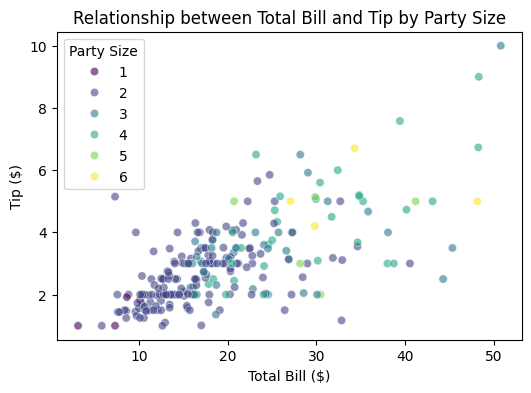

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='size', palette='viridis', alpha=0.6)
plt.title('Relationship between Total Bill and Tip by Party Size')
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.legend(title="Party Size")
plt.show()

**Explain:**

The scatter plot shows that larger parties (lighter colors) tend to have higher total bills and higher tip amounts. This means party size affects both total_bill and tip. Because the relationship between total_bill and tip changes depending on party size, the plot supports the conclusion that party size is a confounder